In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashery/rsna-2023-abdominal-trauma-processed-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rsna-2023-abdominal-trauma-processed-dataset


### Generating 3 views (windows) of images

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Windowing Functions
# -----------------------------

def window_image(img, WL, WW):
    """Apply window level (WL) and window width (WW) to image."""
    img = img.astype(np.float32)
    min_val = WL - WW // 2
    max_val = WL + WW // 2
    windowed = np.clip(img, min_val, max_val)
    windowed = ((windowed - min_val) / (max_val - min_val)) * 255.0
    return windowed.astype(np.uint8)

def apply_brain_window(img):
    return window_image(img, WL=40, WW=80)

def apply_lung_window(img):
    return window_image(img, WL=-600, WW=1500)

def apply_soft_tissue_window(img):
    return window_image(img, WL=50, WW=400)


### Brain Window; Lung Window; Soft Tissue Window

In [3]:

# -----------------------------
# Image Loader
# -----------------------------

def load_images_from_folder(folder, max_images):
    image_paths = []
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith('.png'):
                image_paths.append(os.path.join(root, file))
    image_paths.sort()  # Optional: consistent order
    selected_paths = image_paths[:max_images]
    
    processed = []
    for path in selected_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        brain = apply_brain_window(img)
        lung = apply_lung_window(img)
        soft = apply_soft_tissue_window(img)
        processed.append((img, brain, lung, soft))
    
    return processed

# -----------------------------
# Display Function
# -----------------------------

def display_xth_image(processed_images, index=0):
    if index < 0 or index >= len(processed_images):
        print(f"Invalid index {index}. Total images processed: {len(processed_images)}")
        return
    original, brain, lung, soft = processed_images[index]

    titles = ['Original', 'Brain Window', 'Lung Window', 'Soft Tissue Window']
    images = [original, brain, lung, soft]

    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    for i, ax in enumerate(axs.flat):
        ax.imshow(images[i], cmap='gray')
        ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()




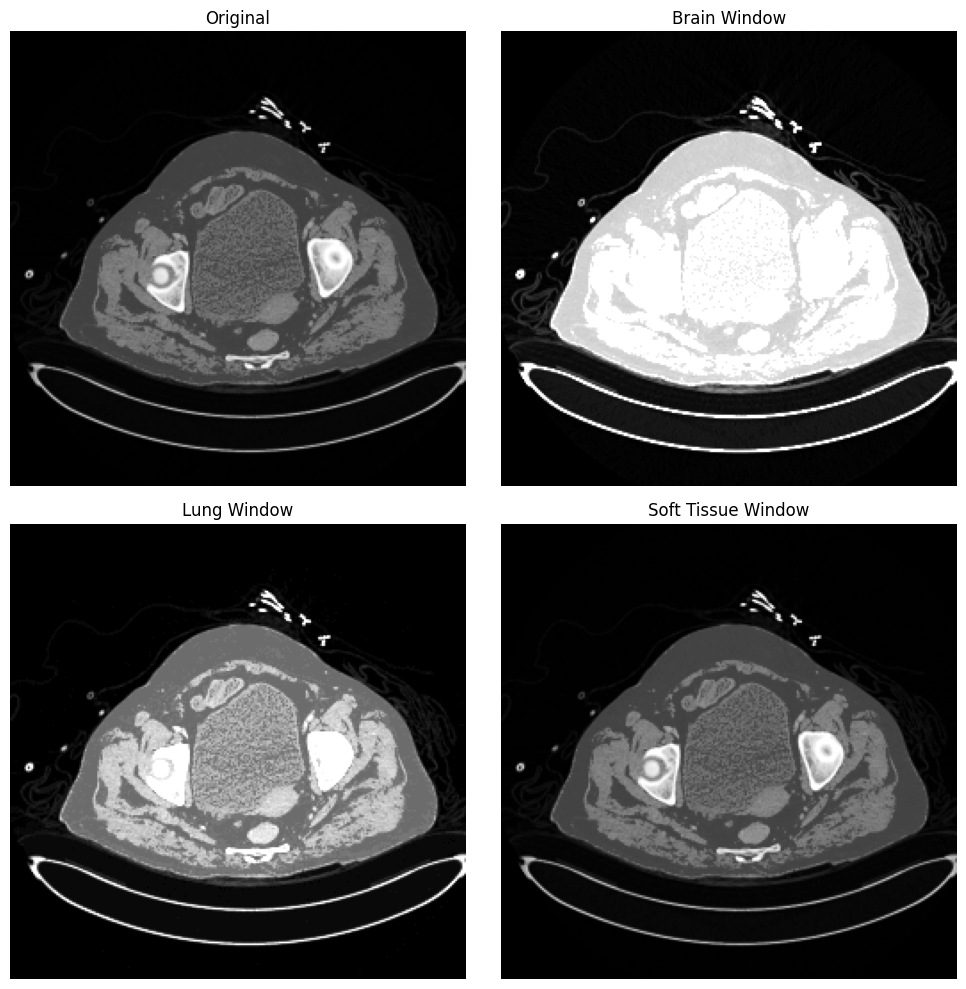

In [4]:
# -----------------------------
# Main Execution
# -----------------------------

if __name__ == "__main__":
    folder_path = "/kaggle/input/rsna-2023-abdominal-trauma-processed-dataset/RSNA2023ProcessedImages/RSNA2023ProcessedImages/10004/21057"
    x = 5  # Number of images to process
    display_index = 1  # Index of the image to display (0 to x-1)

    processed_images = load_images_from_folder(folder_path, x)
    display_xth_image(processed_images, display_index)

## TEST CODE -  

In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import cv2
import pydicom
import matplotlib.pyplot as plt
from math import ceil

%matplotlib inline
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

image_paths = []
for index,(dirname, _, filenames) in enumerate(os.walk('/kaggle/input')):
    for filename in filenames:
        if filename.endswith(".dcm"):
            ## get dicom image paths
            path = os.path.join(dirname, filename)
            #print(path)
            image_paths.append(path)
    if index == 9:
        break
        
    
        
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
len(image_paths)

1266

### Standardize the Image

In [11]:
def standardize_image(dicom_image):
    pixel_array = dicom_image.pixel_array   
    
    if dicom_image.PixelRepresentation == 1:
        bit_shift = dicom_image.BitsAllocated - dicom_image.BitsStored
        dtype = pixel_array.dtype 
        pixel_array = (pixel_array << bit_shift).astype(dtype) >>  bit_shift
    
    if dicom_image.PhotometricInterpretation == "MONOCHROME1":
        pixel_array = 1 - pixel_array
    
    # transform to hounsfield units
    intercept = dicom_image.RescaleIntercept
    slope = dicom_image.RescaleSlope
    pixel_array = pixel_array * slope + intercept
    return pixel_array

### Applying Windowing Technique

In [12]:
def apply_window(image_stack, window, normalize = True):
    
    window_width = window[0]
    window_center = window[1]
    img_min = window_center - window_width//2 #minimum HU level
    img_max = window_center + window_width//2 #maximum HU level
    img = np.clip(image_stack, img_min, img_max)
    
    if normalize:
        img = (img - img_min) / (img_max - img_min)
    return img

### Convert DICOM images to PNG format by applying windowing techniques to highlight specific anatomical features.

In [13]:
def dicom_to_png(dicom_image):
    """
    Read the dicom file and preprocess appropriately.
    """
    pixel_array = standardize_image(dicom_image)
    
    windows = [(2,1),(2048,1),(300,150)]
    imgs = []
    for window in windows:
        windowed_array = apply_window(pixel_array,window, normalize = True)
        img = (windowed_array * 255).astype(np.uint8)
        img = cv2.resize(img, (256,256))
        imgs.append(img)
    
    return np.stack(imgs,axis=-1)

### Show images before preprocessing

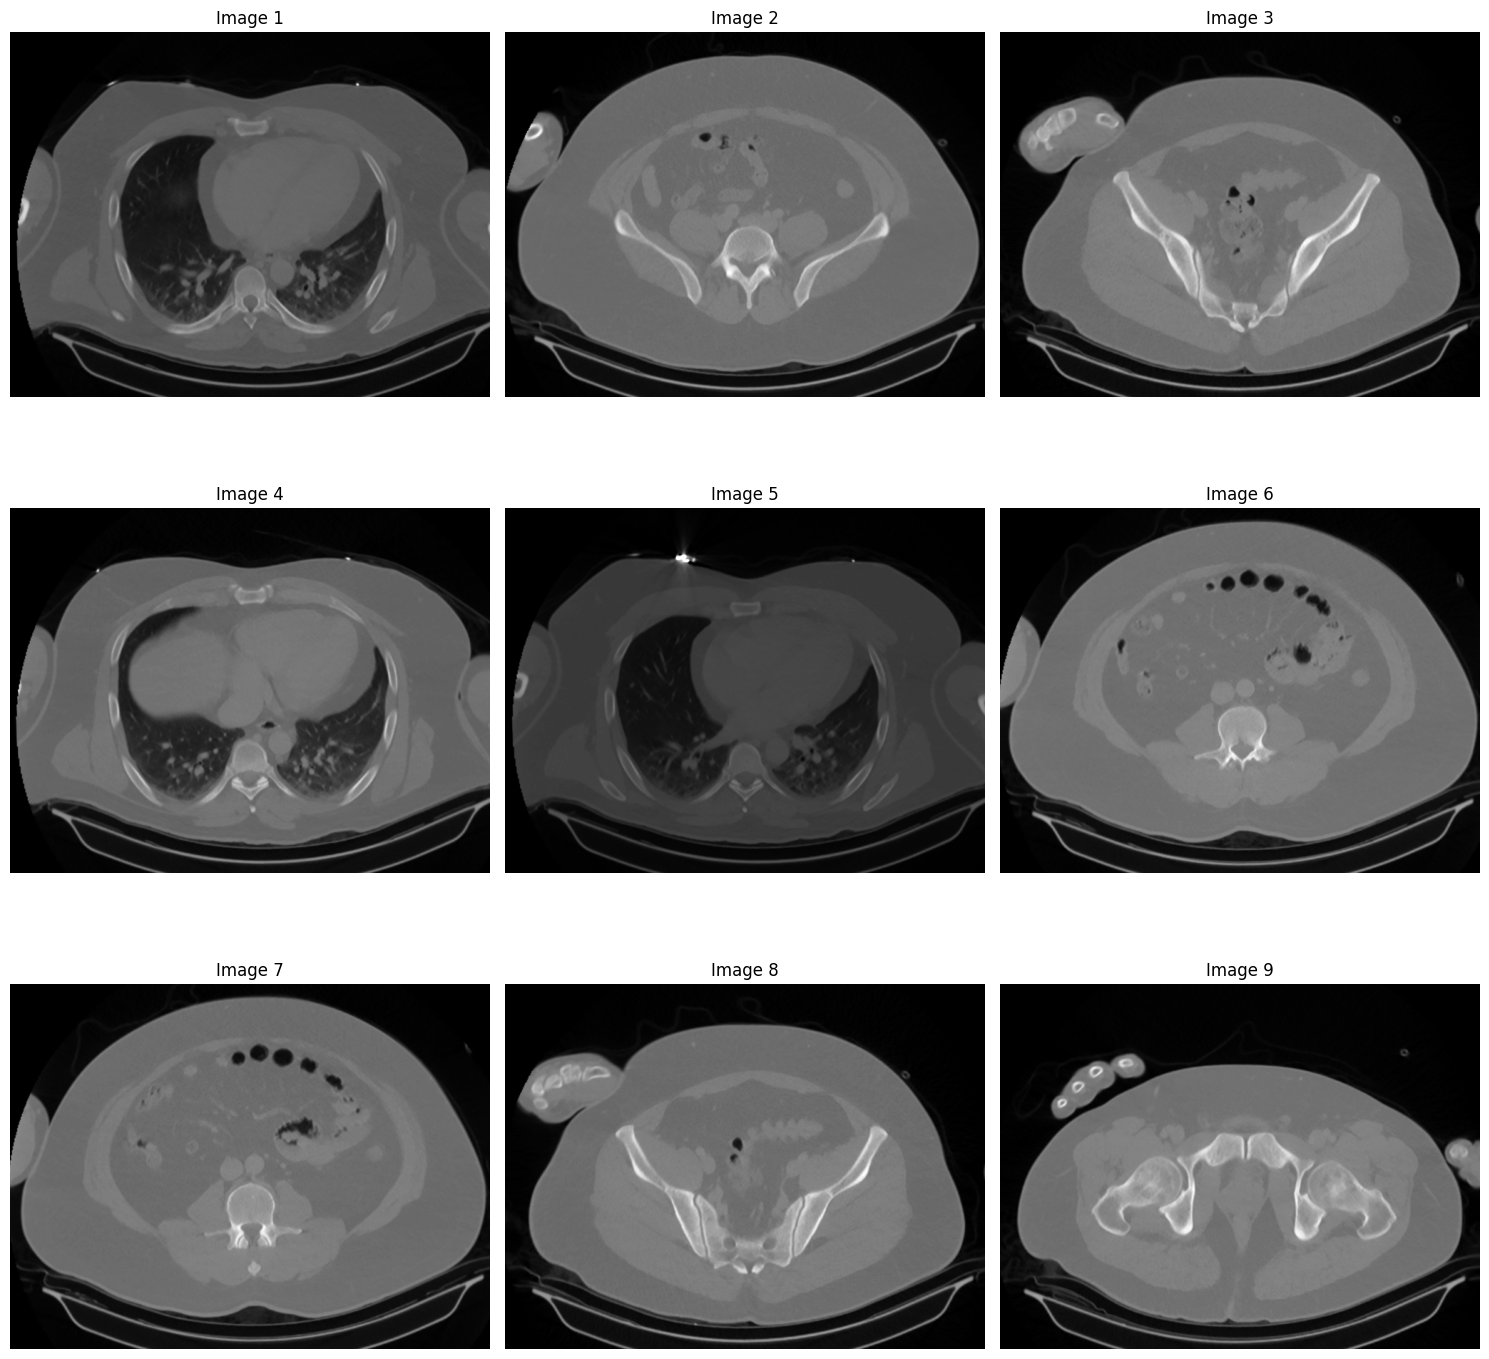

In [14]:
num_images = len(image_paths[:9])
num_rows = ceil(num_images / 3)
fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))

for i, path in enumerate(image_paths[:9]):
    dicom_data = pydicom.dcmread(path)
    img = dicom_data.pixel_array
    row = i // 3
    col = i % 3
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Image {i+1}")

#Remove empty subplots
for i in range(num_images, num_rows*3):
    row = i // 3
    col = i % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

### Process 9 sample images and show them

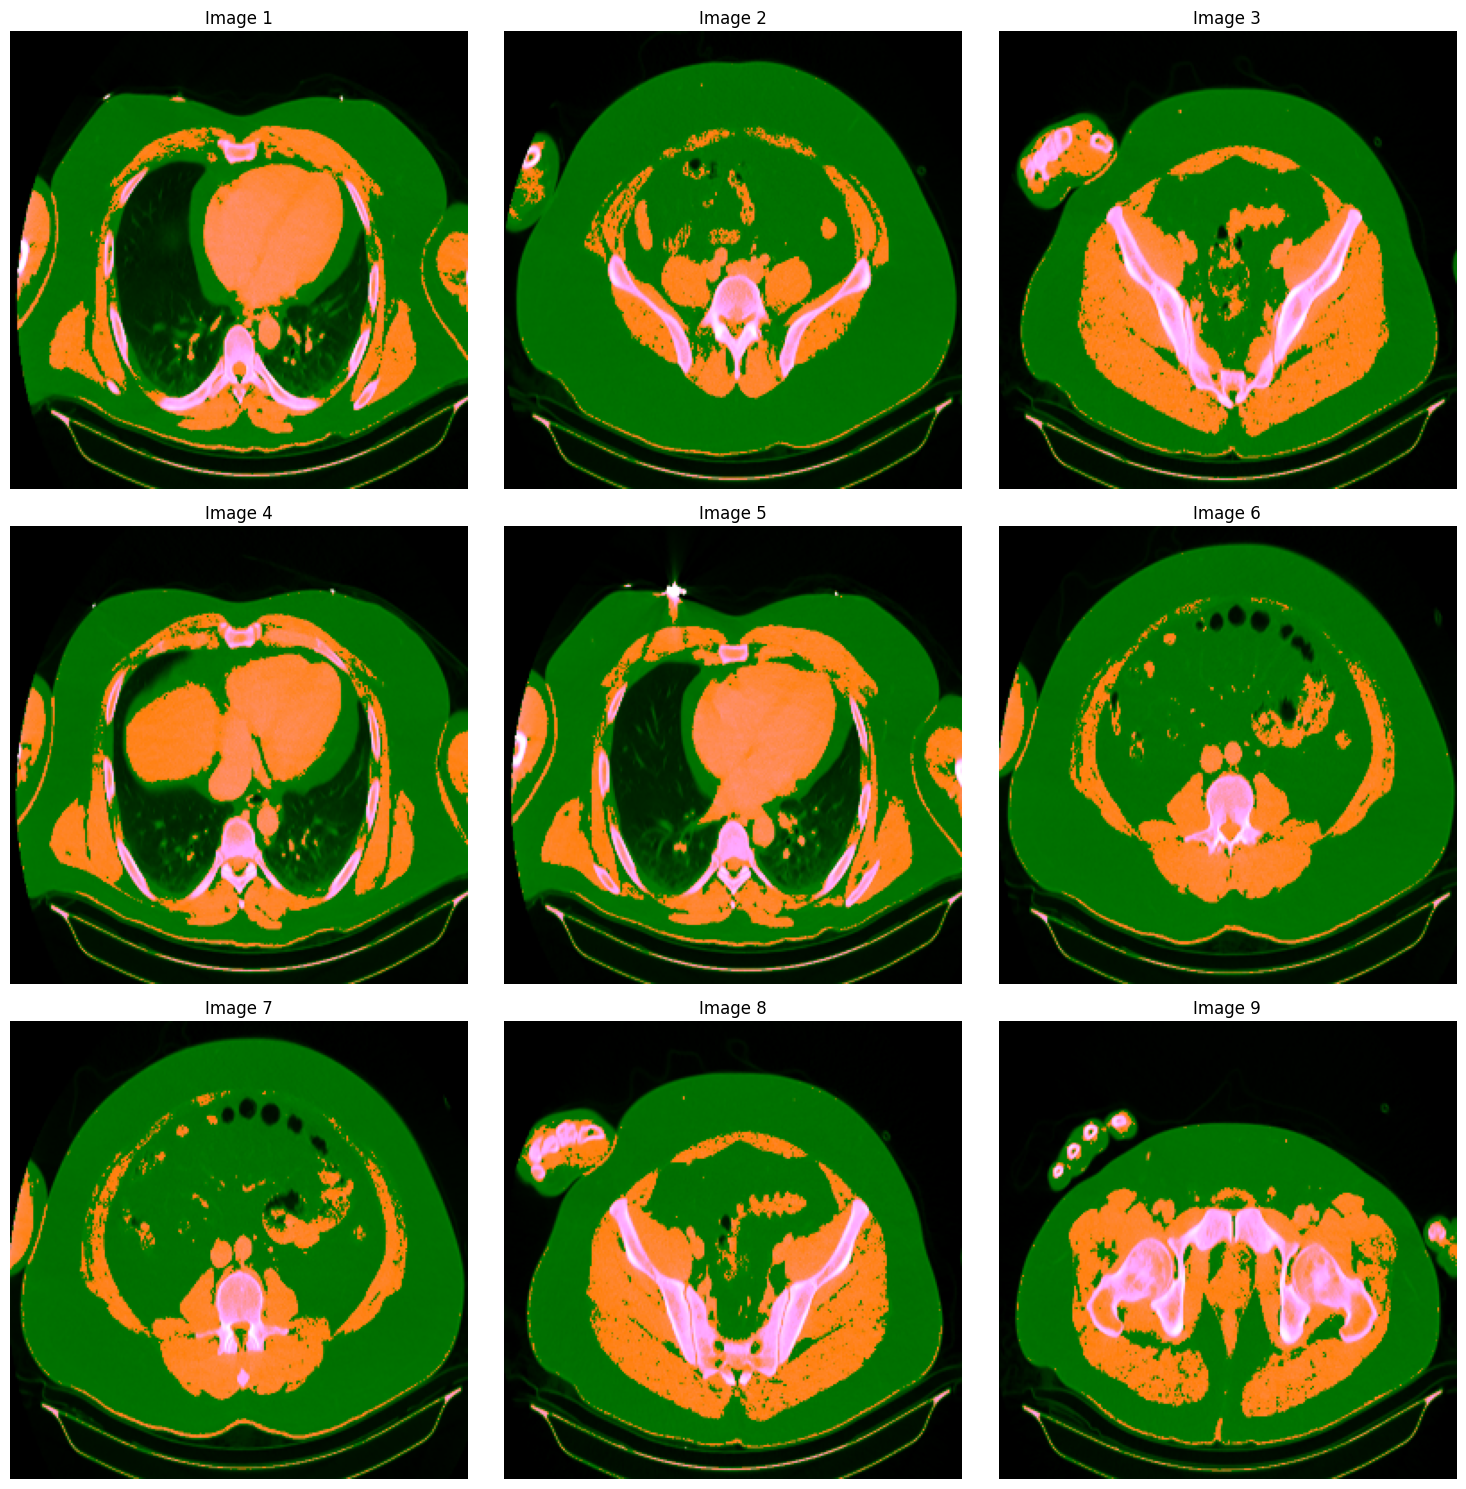

In [15]:
num_images = min(len(image_paths), 9)
num_rows = (num_images + 2) // 3
fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))

for i, path in enumerate(image_paths[:9]):
    dicom_data = pydicom.dcmread(path)
    img = dicom_to_png(dicom_data)
    row = i // 3
    col = i % 3
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Image {i+1}")

# Remove empty subplots
for i in range(num_images, num_rows*3):
    row = i // 3
    col = i % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()